## Price Elasticity Analysis

**Input:** data/ventas_clean.csv

**Business problem:** Should the seller raise prices? Under +200% inflation, the answer is not obvious.


## Setup

In [1]:
import os
import pathlib
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

ROOT = pathlib.Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)

C = dict(
    bg='#0A0E17', surface='#111827', surf2='#1A2235',
    border='#1E2D45', accent='#00E5A0', gold='#F5C842',
    red='#FF4D6A', blue='#4D9FFF', orange='#E8883A',
    text='#E8EDF5', muted='#6B7A99',
)
YEAR_COLORS = {2023: C['blue'], 2024: C['accent'], 2025: C['gold'], 2026: C['orange']}

mpl.rcParams.update({
    'figure.facecolor': C['bg'], 'axes.facecolor': C['surface'],
    'axes.edgecolor': C['border'], 'axes.labelcolor': C['muted'],
    'axes.titlecolor': C['text'], 'text.color': C['text'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': C['border'], 'grid.linewidth': 0.6,
    'xtick.color': C['muted'], 'ytick.color': C['muted'],
    'font.family': 'DejaVu Sans',
})

os.makedirs(ROOT / 'plots', exist_ok=True)

df = pd.read_csv(ROOT / 'data' / 'ventas_clean.csv', parse_dates=['date'])
print(f'Dataset loaded: {len(df):,} orders')
print(f'Date range: {df["date"].min().date()} -> {df["date"].max().date()}')
print(f'Price range: ${df["unit_price"].min():,.0f} - ${df["unit_price"].max():,.0f} ARS (nominal)')
print(f'Real price range: ${df["unit_price_real"].min():,.0f} - ${df["unit_price_real"].max():,.0f} ARS (Jan 2023)')

Dataset loaded: 353 orders
Date range: 2023-01-06 -> 2026-04-01
Price range: $399 - $29,000 ARS (nominal)
Real price range: $241 - $6,885 ARS (Jan 2023)


## Monthly Price-Demand Series

In [2]:
monthly = (
    df.groupby(df['date'].dt.to_period('M'))
    .agg(
        quantity = ('order_id', 'count'),
        price_nominal = ('unit_price', 'median'),
        price_real = ('unit_price_real','median'),
        revenue_real = ('gross_revenue_real','sum'),
    )
    .reset_index()
)
monthly.columns = ['period','quantity','price_nominal','price_real','revenue_real']
monthly['ds'] = monthly['period'].dt.to_timestamp()
monthly['year'] = monthly['ds'].dt.year

clean = monthly.dropna(subset=['price_real','quantity']).copy()
clean = clean[clean['quantity'] > 0].reset_index(drop=True)

print(f'Monthly series: {len(monthly)} months')
print(f'Clean (for model): {len(clean)} months')
print()
print('Real price evolution (Jan 2023 ARS):')
print(f'Min: ${clean["price_real"].min():,.0f}')
print(f'Max: ${clean["price_real"].max():,.0f}')
print(f'Range: {clean["price_real"].max() / clean["price_real"].min():.1f}x - sufficient variation for elasticity')
print()
print('Nominal price evolution (raw ARS):')
print(f'2023 median: ${clean[clean["year"]==2023]["price_nominal"].median():,.0f}')
print(f'2026 median: ${clean[clean["year"]==2026]["price_nominal"].median():,.0f}')
print(f'Nominal growth: {clean[clean["year"]==2026]["price_nominal"].median() / clean[clean["year"]==2023]["price_nominal"].median():.1f}x')

Monthly series: 40 months
Clean (for model): 39 months

Real price evolution (Jan 2023 ARS):
Min: $654
Max: $1,930
Range: 3.0x - sufficient variation for elasticity

Nominal price evolution (raw ARS):
2023 median: $1,449
2026 median: $16,499
Nominal growth: 11.4x


## Log-Log Regression

In [3]:
# Log-transform both variables
clean['log_price'] = np.log(clean['price_real'])
clean['log_quantity'] = np.log(clean['quantity'])

# Verify sufficient price variation 
log_price_range = clean['log_price'].max() - clean['log_price'].min()
print(f'Log-price range: {log_price_range:.2f} (rule of thumb: > 0.5 for reliable elasticity)')
print(f'Sufficient variation: {"YES" if log_price_range > 0.5 else "NO - interpret with caution"}')

corr = clean[['log_price','log_quantity']].corr().iloc[0,1]
print(f'Pearson r (log price vs log quantity): {corr:.3f}')
print(f'Direction: {"negative (higher price -> fewer orders, as expected)" if corr < 0 else "positive (unexpected - check data)"}')

Log-price range: 1.08 (rule of thumb: > 0.5 for reliable elasticity)
Sufficient variation: YES
Pearson r (log price vs log quantity): -0.302
Direction: negative (higher price -> fewer orders, as expected)


## Estimate Aggregate Price Elasticity

In [4]:
slope, intercept, r_value, p_value, std_err = stats.linregress(
    clean['log_price'], clean['log_quantity']
)

elasticity = slope
r2 = r_value ** 2

print('-AGGREGATE PRICE ELASTICITY-')
print()
print(f'Elasticity (epsilon): {elasticity:.4f}')
print(f'R-squared: {r2:.4f}')
print(f'P-value: {p_value:.6f}')
print(f'Std error: {std_err:.4f}')
print(f'95% CI: [{elasticity - 1.96*std_err:.3f}, {elasticity + 1.96*std_err:.3f}]')
print()
demand_type = 'INELASTIC' if abs(elasticity) < 1 else 'ELASTIC'
print(f'Demand type: {demand_type}')
if abs(elasticity) < 1:
    print(f'A 10% price increase -> only {abs(elasticity)*10:.1f}% fewer orders')
    print('Revenue INCREASES with price increases')
    print('The seller has pricing power')
else:
    print(f'A 10% price increase -> {abs(elasticity)*10:.1f}% fewer orders')
    print('Revenue DECREASES with price increases')
    print('Price increases must be justified by cost coverage only')

-AGGREGATE PRICE ELASTICITY-

Elasticity (epsilon): -0.6539
R-squared: 0.0912
P-value: 0.061770
Std error: 0.3394
95% CI: [-1.319, 0.011]

Demand type: INELASTIC
A 10% price increase -> only 6.5% fewer orders
Revenue INCREASES with price increases
The seller has pricing power


## Empirical Demand Curve

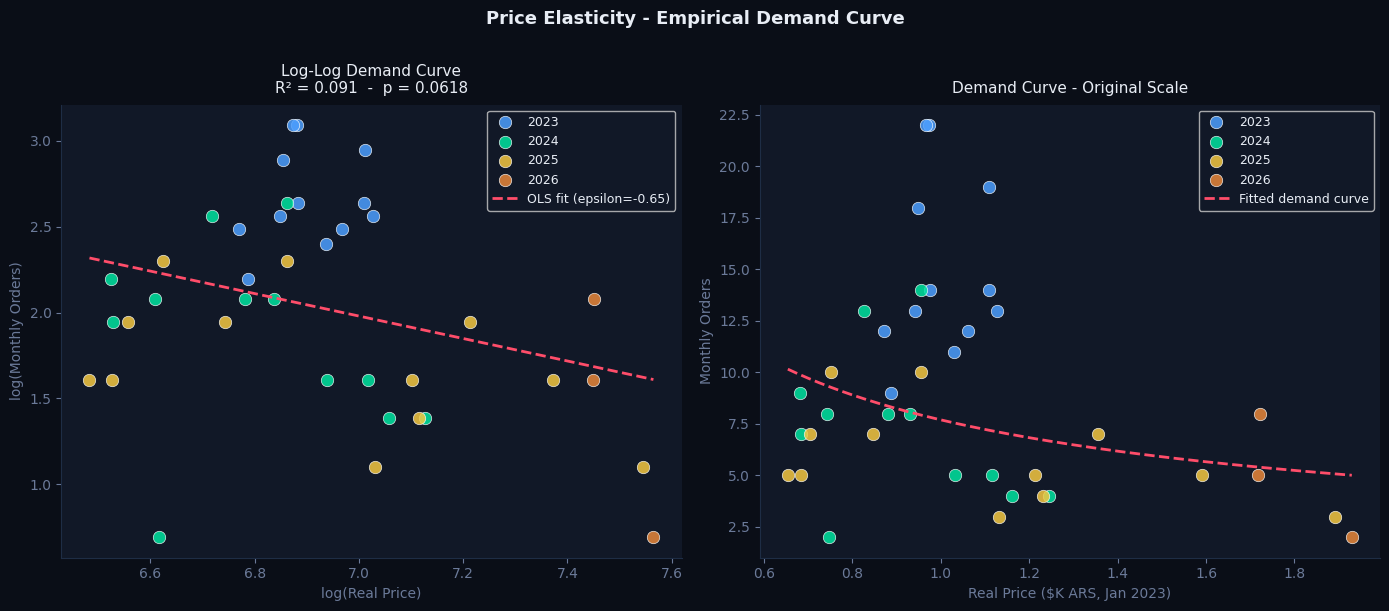

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor=C['bg'])
fig.suptitle('Price Elasticity - Empirical Demand Curve',
             fontsize=13, fontweight='bold', color=C['text'], y=1.01)

# Left: demand curve (log-log space)
for year, g in clean.groupby('year'):
    ax1.scatter(g['log_price'], g['log_quantity'],
                color=YEAR_COLORS.get(year, C['muted']),
                s=80, alpha=0.85, label=str(year),
                edgecolors='white', linewidths=0.5, zorder=3)

x_fit = np.linspace(clean['log_price'].min(), clean['log_price'].max(), 100)
y_fit = intercept + slope * x_fit
ax1.plot(x_fit, y_fit, color=C['red'], linewidth=2, linestyle='--',
         label=f'OLS fit (epsilon={elasticity:.2f})', zorder=4)

ax1.set_xlabel('log(Real Price)')
ax1.set_ylabel('log(Monthly Orders)')
ax1.set_title(f'Log-Log Demand Curve\nR² = {r2:.3f}  -  p = {p_value:.4f}', fontsize=11, pad=8)
ax1.legend(fontsize=9)
ax1.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax1.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax1.spines[sp].set_color(C['border'])

# Right: original scale with fitted curve
for year, g in clean.groupby('year'):
    ax2.scatter(g['price_real'] / 1e3, g['quantity'],
                color=YEAR_COLORS.get(year, C['muted']),
                s=80, alpha=0.85, label=str(year),
                edgecolors='white', linewidths=0.5, zorder=3)

p_range = np.linspace(clean['price_real'].min(), clean['price_real'].max(), 200)
q_fit = np.exp(intercept) * p_range ** slope
ax2.plot(p_range / 1e3, q_fit, color=C['red'], linewidth=2,
         linestyle='--', label='Fitted demand curve', zorder=4)

ax2.set_xlabel('Real Price ($K ARS, Jan 2023)')
ax2.set_ylabel('Monthly Orders')
ax2.set_title('Demand Curve - Original Scale', fontsize=11, pad=8)
ax2.legend(fontsize=9)
ax2.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax2.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax2.spines[sp].set_color(C['border'])

plt.tight_layout()
plt.savefig(ROOT / 'plots' / '20_demand_curve.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

## Benchmark Against Literature

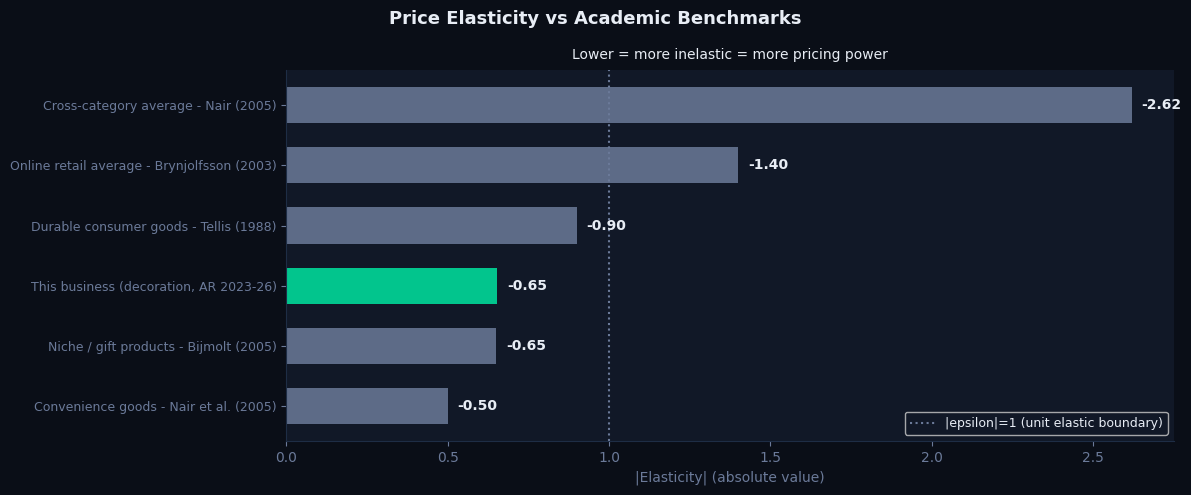

Positioning:
This business ranks #3 most inelastic out of 6 benchmarks
|epsilon| = 0.65 vs cross-category avg of 2.62


In [6]:
benchmarks = [
    ('This business (decoration, AR 2023-26)', elasticity),
    ('Convenience goods - Nair et al. (2005)', -0.50),
    ('Niche / gift products - Bijmolt (2005)', -0.65),
    ('Durable consumer goods - Tellis (1988)', -0.90),
    ('Cross-category average - Nair (2005)', -2.62),
    ('Online retail average - Brynjolfsson (2003)',-1.40),
]

bm = pd.DataFrame(benchmarks, columns=['context','elasticity'])
bm = bm.sort_values('elasticity', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=C['bg'])
fig.suptitle('Price Elasticity vs Academic Benchmarks',
             fontsize=13, fontweight='bold', color=C['text'])

colors = [C['accent'] if 'This business' in row['context'] else C['muted']
          for _, row in bm.iterrows()]
bars = ax.barh(range(len(bm)), bm['elasticity'].abs(),
               color=colors, alpha=0.85, height=0.6)

for bar, (_, row) in zip(bars, bm.iterrows()):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            f'{row["elasticity"]:.2f}',
            va='center', fontsize=10, color=C['text'], fontweight='bold')

ax.set_yticks(range(len(bm)))
ax.set_yticklabels([c[:60]+'...' if len(c) > 60 else c for c in bm['context']], fontsize=9)
ax.axvline(x=1, color=C['muted'], linestyle=':', linewidth=1.5,
           label='|epsilon|=1 (unit elastic boundary)')
ax.set_xlabel('|Elasticity| (absolute value)')
ax.set_title('Lower = more inelastic = more pricing power', fontsize=10, pad=8)
ax.legend(fontsize=9)
ax.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax.spines[sp].set_color(C['border'])

plt.tight_layout()
plt.savefig(ROOT / 'plots' / '21_benchmarks.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

print('Positioning:')
our_rank = bm[bm['context'].str.contains('This business')].index[0]
print(f'This business ranks #{our_rank+1} most inelastic out of {len(bm)} benchmarks')
print(f'|epsilon| = {abs(elasticity):.2f} vs cross-category avg of 2.62')

## Product Level Elasticity


In [7]:
item_elasticities = []

for item_id, group in df.groupby('item_id'):
    g = (
        group.groupby(group['date'].dt.to_period('M'))
        .agg(
            quantity = ('order_id', 'count'),
            price_real = ('unit_price_real', 'median'),
        )
        .reset_index()
        .dropna()
    )
    g = g[g['quantity'] > 0]

    if len(g) < 6:
        continue
    price_cv = g['price_real'].std() / g['price_real'].mean()
    if price_cv < 0.15:
        continue

    try:
        s, i, r, p, se = stats.linregress(np.log(g['price_real']), np.log(g['quantity']))
        item_elasticities.append({
            'item_id': item_id,
            'elasticity': s,
            'r2': r**2,
            'p_value': p,
            'n_months': len(g),
            'price_cv': price_cv,
            'avg_revenue':group['gross_revenue'].sum(),
        })
    except Exception:
        pass

item_df = pd.DataFrame(item_elasticities).sort_values('elasticity')

print(f'Items with enough data for estimation: {len(item_df)}')
print(f'Significant at p<0.10: {(item_df["p_value"] < 0.10).sum()}')
print(f'Significant at p<0.20: {(item_df["p_value"] < 0.20).sum()}')
print()
print('Elasticity distribution across items:')
print(item_df['elasticity'].describe().round(3).to_string())

Items with enough data for estimation: 8
Significant at p<0.10: 1
Significant at p<0.20: 1

Elasticity distribution across items:
count    8.000
mean     0.236
std      0.571
min     -0.100
25%      0.000
50%      0.000
75%      0.155
max      1.626


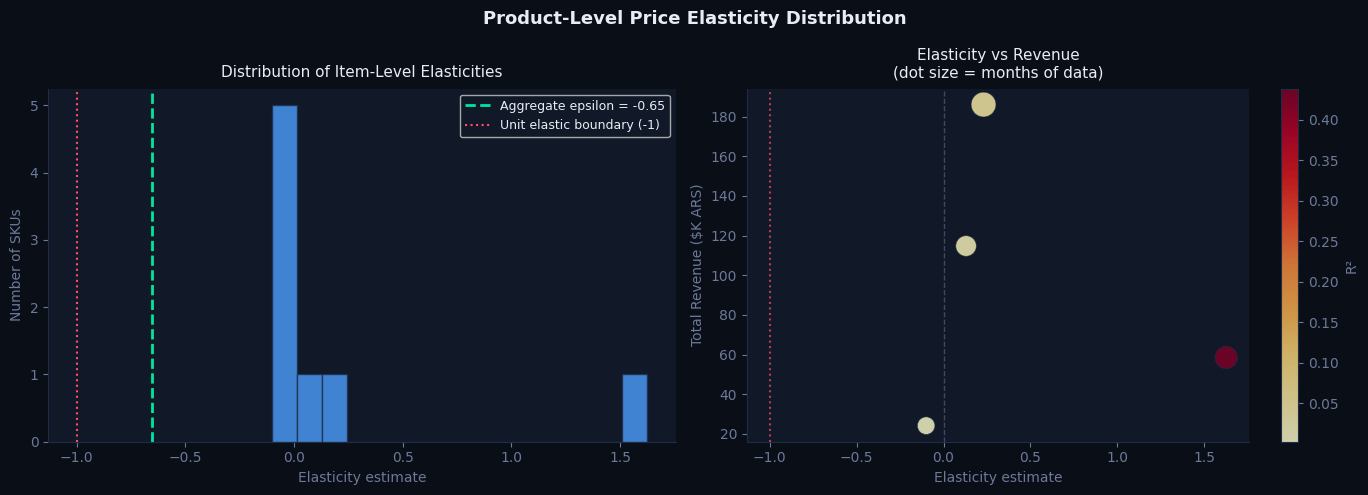

In [8]:
if len(item_df) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor=C['bg'])
    fig.suptitle('Product-Level Price Elasticity Distribution',
                 fontsize=13, fontweight='bold', color=C['text'])

    # Histogram of elasticities
    colors_hist = [C['accent'] if e > -1 else C['red'] for e in item_df['elasticity']]
    ax1.hist(item_df['elasticity'], bins=15, color=C['blue'], alpha=0.8, edgecolor=C['border'])
    ax1.axvline(elasticity, color=C['accent'], linewidth=2, linestyle='--',
                label=f'Aggregate epsilon = {elasticity:.2f}')
    ax1.axvline(-1, color=C['red'], linewidth=1.5, linestyle=':',
                label='Unit elastic boundary (-1)')
    ax1.set_xlabel('Elasticity estimate')
    ax1.set_ylabel('Number of SKUs')
    ax1.set_title('Distribution of Item-Level Elasticities', fontsize=11, pad=8)
    ax1.legend(fontsize=9)
    ax1.set_facecolor(C['surface'])
    for sp in ['top','right']:
        ax1.spines[sp].set_visible(False)
    for sp in ['left','bottom']:
        ax1.spines[sp].set_color(C['border'])

    # Elasticity vs revenue 
    sc = ax2.scatter(
        item_df['elasticity'],
        item_df['avg_revenue'] / 1e3,
        s=item_df['n_months'] * 20,
        c=item_df['r2'],
        cmap='YlOrRd', alpha=0.8, edgecolors=C['border'], linewidths=0.5
    )
    ax2.axvline(-1, color=C['red'], linewidth=1.5, linestyle=':', alpha=0.7)
    ax2.axvline(0, color=C['muted'], linewidth=1, linestyle='--', alpha=0.5)
    plt.colorbar(sc, ax=ax2, label='R²')
    ax2.set_xlabel('Elasticity estimate')
    ax2.set_ylabel('Total Revenue ($K ARS)')
    ax2.set_title('Elasticity vs Revenue\n(dot size = months of data)', fontsize=11, pad=8)
    ax2.set_facecolor(C['surface'])
    for sp in ['top','right']:
        ax2.spines[sp].set_visible(False)
    for sp in ['left','bottom']:
        ax2.spines[sp].set_color(C['border'])

    plt.tight_layout()
    plt.savefig(ROOT / 'plots' / '22_item_elasticity.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
    plt.show()
else:
    print('Not enough items with sufficient price variation for product-level analysis.')

## Inflation Pass-Through vs Elasticity

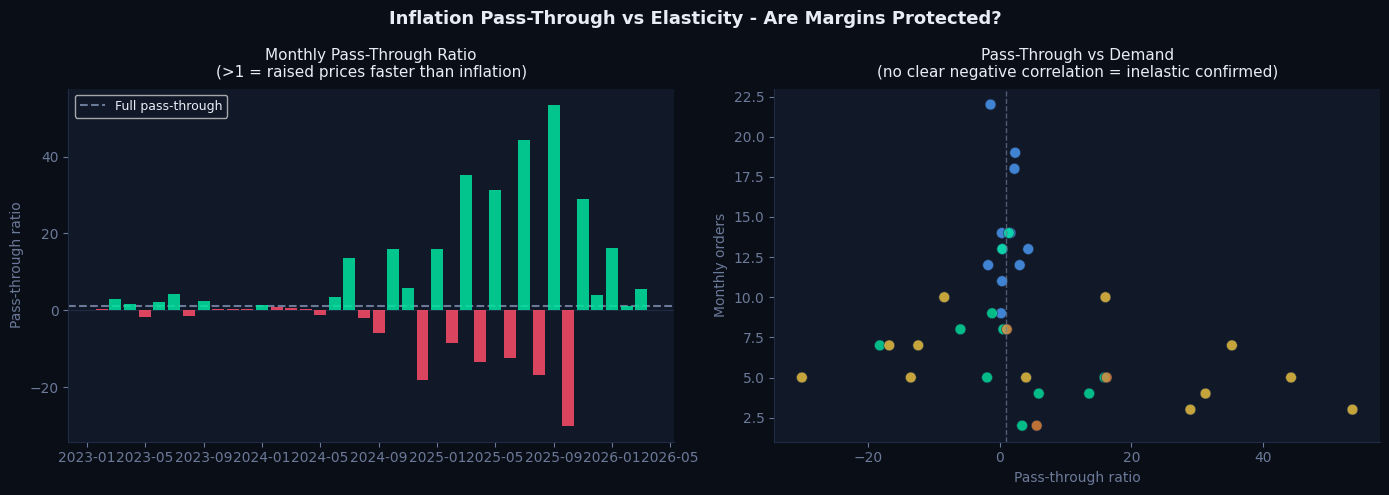

Avg pass-through ratio: 4.78
Months above 1.0: 20/38 (53%)
Interpretation: seller protected margins


In [9]:
# Compute monthly pass-through
monthly_pt = (
    df.groupby(df['date'].dt.to_period('M'))
    .agg(
        price_nom = ('unit_price', 'median'),
        cpi = ('cpi_index', 'mean'),
    )
    .reset_index()
)
monthly_pt.columns = ['period','price_nom','cpi']
monthly_pt['ds'] = monthly_pt['period'].dt.to_timestamp()
monthly_pt = monthly_pt.dropna()

monthly_pt['price_change_pct'] = monthly_pt['price_nom'].pct_change() * 100
monthly_pt['cpi_change_pct'] = monthly_pt['cpi'].pct_change() * 100
monthly_pt['pass_through'] = (
    monthly_pt['price_change_pct'] / monthly_pt['cpi_change_pct']
).replace([np.inf, -np.inf], np.nan)

pt_clean = monthly_pt['pass_through'].dropna()
avg_pt = pt_clean.mean()
months_above = (pt_clean >= 1).sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor=C['bg'])
fig.suptitle('Inflation Pass-Through vs Elasticity - Are Margins Protected?',
             fontsize=13, fontweight='bold', color=C['text'])

colors_pt = [C['accent'] if v >= 1 else C['red'] for v in monthly_pt['pass_through'].fillna(0)]
ax1.bar(monthly_pt['ds'].iloc[1:], monthly_pt['pass_through'].iloc[1:],
        width=25, color=colors_pt[1:], alpha=0.85, zorder=3)
ax1.axhline(1.0, color=C['muted'], linewidth=1.5, linestyle='--', label='Full pass-through')
ax1.axhline(0.0, color=C['border'], linewidth=0.8)
ax1.set_title('Monthly Pass-Through Ratio\n(>1 = raised prices faster than inflation)', fontsize=11, pad=8)
ax1.set_ylabel('Pass-through ratio')
ax1.legend(fontsize=9)
ax1.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax1.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax1.spines[sp].set_color(C['border'])

# Quadrant chart: pass-through vs elasticity by month
combined = monthly_pt.merge(
    monthly[['ds','quantity','price_real']].rename(columns={'ds':'ds'}), on='ds', how='inner'
).dropna()

ax2.scatter(combined['pass_through'], combined['quantity'],
            c=combined['ds'].dt.year.map(YEAR_COLORS).fillna(C['muted']),
            s=60, alpha=0.8, edgecolors=C['border'], linewidths=0.5)
ax2.axvline(1, color=C['muted'], linewidth=1, linestyle='--', alpha=0.7)
ax2.set_xlabel('Pass-through ratio')
ax2.set_ylabel('Monthly orders')
ax2.set_title('Pass-Through vs Demand\n(no clear negative correlation = inelastic confirmed)', fontsize=11, pad=8)
ax2.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax2.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax2.spines[sp].set_color(C['border'])

plt.tight_layout()
plt.savefig(ROOT / 'plots' / '23_passthrough.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

print(f'Avg pass-through ratio: {avg_pt:.2f}')
print(f'Months above 1.0: {months_above}/{len(pt_clean)} ({months_above/len(pt_clean)*100:.0f}%)')
print(f'Interpretation: seller {"protected margins" if avg_pt >= 0.8 else "absorbed inflation - margin pressure"}')

## Business Implications

In [10]:
print('PRICE ELASTICITY - BUSINESS IMPLICATIONS')
print()
print(f'Aggregate elasticity: {elasticity:.3f}')
print(f'Demand type: {"INELASTIC" if abs(elasticity) < 1 else "ELASTIC"}')
print(f'R-squared: {r2:.3f}')
print(f'Avg pass-through: {avg_pt:.2f}')
print()

if abs(elasticity) < 1:
    print('FINDING: Inelastic demand - seller has pricing power')
    print()
    print('Implications:')
    print(f'1. A 10% price increase reduces orders by only {abs(elasticity)*10:.1f}%')
    print(f'-> Net revenue effect: +{(1.10 * (1 - abs(elasticity)*0.10) - 1)*100:.1f}%')
    print('2. Premium positioning is justified - buyers are not primarily price-driven')
    print('3. Price increases to cover cost inflation should NOT be feared')
    print('4. Focus marketing on quality/uniqueness, not price competitiveness')
else:
    print('FINDING: Elastic demand - price increases hurt revenue')
    print()
    print('Implications:')
    print(f'1. A 10% price increase reduces orders by {abs(elasticity)*10:.1f}%')
    print(f'-> Net revenue effect: {(1.10 * (1 - abs(elasticity)*0.10) - 1)*100:.1f}%')
    print('2. Price increases must be limited to cost coverage')
    print('3. Promotions and discounts are more effective than premium pricing')

PRICE ELASTICITY - BUSINESS IMPLICATIONS

Aggregate elasticity: -0.654
Demand type: INELASTIC
R-squared: 0.091
Avg pass-through: 4.78

FINDING: Inelastic demand - seller has pricing power

Implications:
1. A 10% price increase reduces orders by only 6.5%
-> Net revenue effect: +2.8%
2. Premium positioning is justified - buyers are not primarily price-driven
3. Price increases to cover cost inflation should NOT be feared
4. Focus marketing on quality/uniqueness, not price competitiveness


## Limitations and Caveats

**Methodological:**
- OLS assumes a linear relationship in log-log space, true elasticity may vary across price ranges
- We estimate own-price elasticity only, cross-price (competitor) effects are not captured
- Monthly aggregation loses within-month dynamics (promotions, flash sales)

**Data:**
- ~40 months of history, limited for capturing structural breaks in consumer behavior
- Real prices depend on IPC accuracy, INDEC estimates may not reflect actual market inflation
- Product mix changed over time, the catalog in 2023 differs from 2026

**Interpretation:**
- Product-level estimates are directional only, sample sizes are too small for precise estimates
- Elasticity may differ by province, season, or customer segment (not captured here)
- The 'natural experiment' assumption requires that no other major demand shocks occurred